In [71]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/RaySilvaP/TelecomX-2/refs/heads/main/TelecomX_2_Data_.csv')
df.drop(['customerID', 'Contas_Diarias', 'gender'], axis=1, inplace=True)

In [72]:
colunas_converter = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling',
    'Churn']

df[colunas_converter] = df[colunas_converter].apply(
    lambda col: col.map({'Yes': 1, 'No': 0})
)

In [73]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = [
    "InternetService",
    "Contract",
    "PaymentMethod"
]

encoder_drop = OneHotEncoder(
    handle_unknown = 'ignore',
    drop=['No'],
    sparse_output=False)

encoder_keep = OneHotEncoder(
    handle_unknown = 'ignore',
    sparse_output=False)


one_hot_enc = make_column_transformer(
    (encoder_drop, cols_to_encode[:1]),
    (encoder_keep, cols_to_encode[1:]),
    remainder='passthrough')

df = one_hot_enc.fit_transform(df)
df = pd.DataFrame(df, columns=one_hot_enc.get_feature_names_out())
df.columns = df.columns.str.replace(r"(onehotencoder-\d+__|remainder__)", "", regex=True)

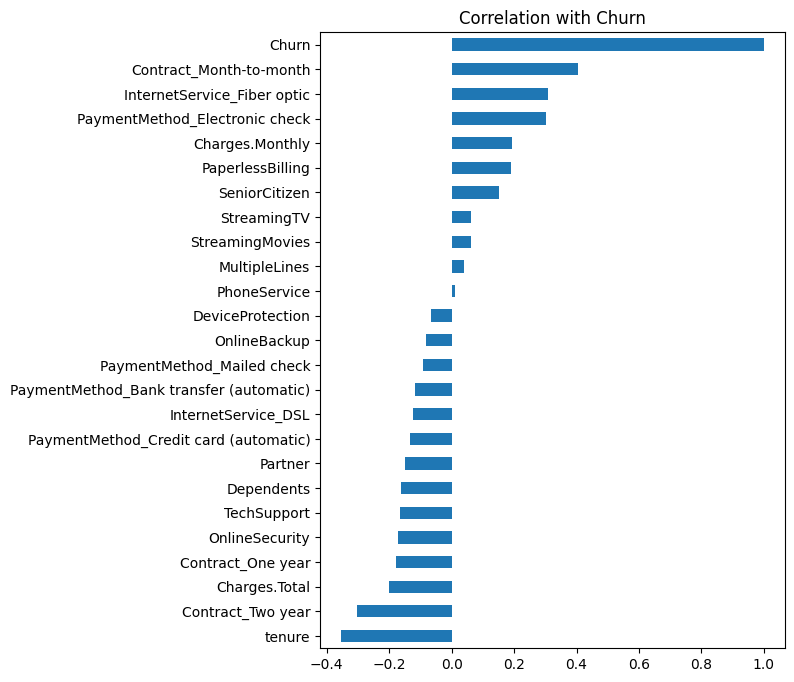

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr()["Churn"].sort_values()

plt.figure(figsize=(6,8))
corr.plot(kind="barh")
plt.title("Correlation with Churn")
plt.show()

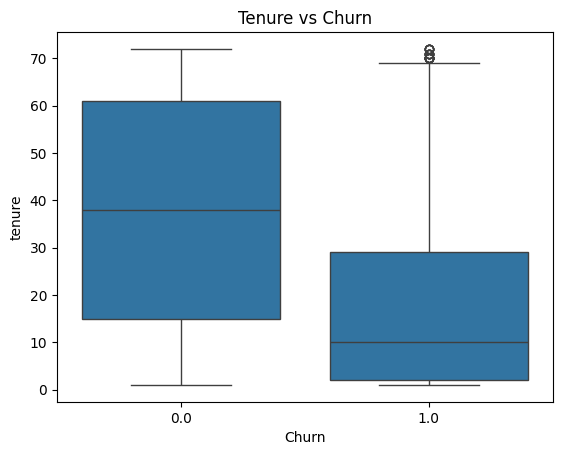

In [75]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tenure vs Churn")
plt.show()

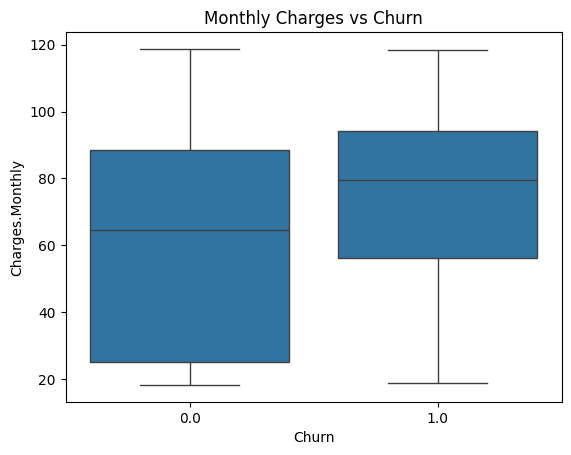

In [76]:
sns.boxplot(x="Churn", y="Charges.Monthly", data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

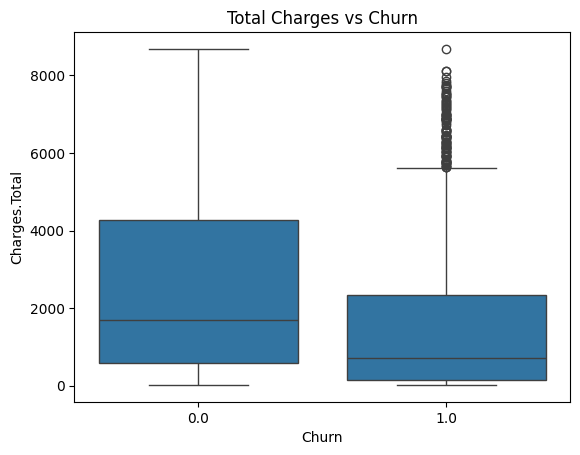

In [77]:
sns.boxplot(x="Churn", y="Charges.Total", data=df)

plt.title("Total Charges vs Churn")
plt.show()

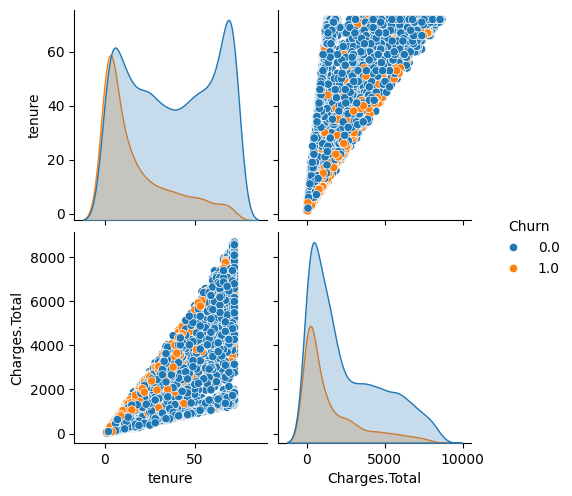

In [78]:
sns.pairplot(
    df[["tenure", "Charges.Total", "Churn"]],
    hue="Churn"
)

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## **Dummy Classifier**
O Dummy Classifier foi utilizado como modelo de referência inicial (baseline), pois ele realiza previsões simples sem aprender padrões dos dados, geralmente prevendo sempre a classe majoritária. A utilização desse modelo permite estabelecer um nível mínimo de desempenho esperado, servindo como parâmetro para verificar se os modelos mais complexos realmente estão aprendendo informações relevantes do conjunto de dados.

In [80]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)



## **Árvore de Decisão**
A Árvore de Decisão foi selecionada por sua capacidade de capturar relações não lineares entre as variáveis e pela facilidade de interpretação do modelo gerado. Diferentemente de alguns algoritmos lineares, esse método não exige normalização dos dados, pois as decisões são tomadas com base em divisões (splits) nos valores das variáveis. Além disso, árvores de decisão permitem identificar quais atributos possuem maior importância na previsão do churn, auxiliando na compreensão dos fatores que influenciam o comportamento dos clientes.

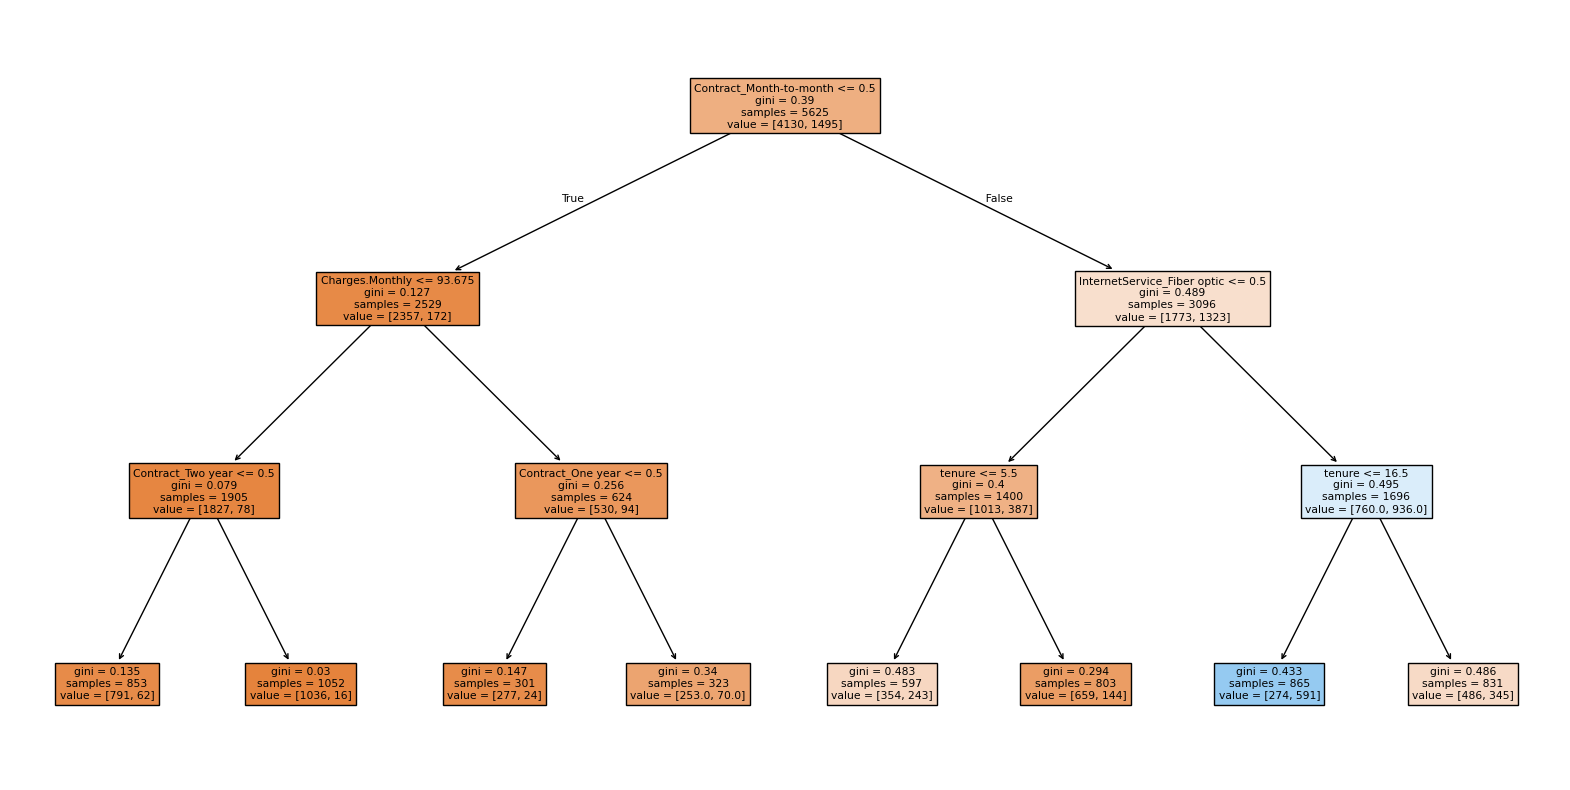

In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=355
)

tree.fit(X_train, y_train)
y_tree_pred = tree.predict(X_test)


plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_train.columns, filled=True)
plt.show()

## **Regressão Logística**
A Regressão Logística foi escolhida por ser um modelo amplamente utilizado em problemas de classificação binária, como a previsão de churn. Esse modelo possui boa interpretabilidade, permitindo compreender como cada variável influencia na probabilidade de um cliente cancelar o serviço. Para a aplicação da Regressão Logística, é importante realizar a normalização das variáveis numéricas, pois o modelo utiliza métodos de otimização baseados em gradiente. Quando as variáveis possuem escalas muito diferentes, algumas podem dominar o processo de aprendizado, prejudicando a convergência do algoritmo e a qualidade das estimativas dos coeficientes.

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

num_cols = ["tenure", "Charges.Monthly", "Charges.Total"]
scaler = StandardScaler()

X_train_norm = X_train.copy()
X_train_norm[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test_norm = X_test.copy()
X_test_norm[num_cols] = scaler.transform(X_test[num_cols])

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
)

log_reg.fit(X_train_norm, y_train)

y_log_reg_pred = log_reg.predict(X_test_norm)


## Validação Cruzada
A validação cruzada foi utilizada para avaliar a capacidade de generalização dos modelos e verificar possíveis problemas de overfitting. Os resultados mostram que a média da validação cruzada foi de aproximadamente 0.78 para a Árvore de Decisão e 0.75 para a Regressão Logística, valores muito próximos das acurácias obtidas no conjunto de teste (0.79 e 0.74, respectivamente). Essa pequena diferença indica que os modelos apresentam bom poder de generalização e não demonstram sinais significativos de overfitting. Dessa forma, pode-se concluir que ambos os modelos conseguem aprender padrões relevantes dos dados sem simplesmente memorizar o conjunto de treinamen

In [83]:
from sklearn.model_selection import cross_val_score

tree_scores = cross_val_score(tree, X_train, y_train, cv=5)
log_scores = cross_val_score(log_model, X_train_norm, y_train, cv=5)

print("Validação Cruzada scores:")
print("Árvore de Decisão:", tree_scores)
print("Média:", tree_scores.mean())
print("Regressão Logística:", log_scores)
print("Média:", log_scores.mean())

Validação Cruzada scores:
Árvore de Decisão: [0.80355556 0.77777778 0.77955556 0.77511111 0.78133333]
Média: 0.7834666666666668
Regressão Logística: [0.74577778 0.768      0.74133333 0.75288889 0.74755556]
Média: 0.7511111111111111


## Comparação dos modelos
A comparação dos modelos mostra diferenças importantes no seu desempenho. O Dummy Classifier obteve uma acurácia de 0.73, mas não conseguiu identificar nenhum caso de churn (recall de 0.00 para a classe 1), pois simplesmente prevê sempre a classe majoritária. A Regressão Logística apresentou uma acurácia semelhante (0.74), porém com desempenho muito melhor na identificação de clientes que cancelam o serviço, alcançando um recall de 0.79 para a classe de churn, o que indica maior capacidade de detectar esses casos. Já a Árvore de Decisão apresentou a maior acurácia geral (0.79) e um bom desempenho na previsão da classe de não churn (recall de 0.94), porém teve um recall menor para a classe de churn (0.39), indicando que muitos clientes que cancelam não foram corretamente identificados. Esses resultados mostram que, embora a Árvore de Decisão tenha maior acurácia, a Regressão Logística apresenta melhor equilíbrio na detecção de clientes que podem abandonar o serviço.

In [84]:
print(f'Dummy:\n {classification_report(y_test, y_dummy_pred)}')
print(f'Logistic Regression:\n {classification_report(y_test, y_log_pred)}')
print(f'Decision Tree:\n {classification_report(y_test, y_tree_pred)}')

Dummy:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.90      0.73      0.81      1033
         1.0       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407

Decision Tree:
               precision    recall  f1-score   support

         0.0       0.81      0.94      0.87      1033
         1.0       0.69      0.39      0.50       374

    accuracy                           0.79      1407
   macro avg       0.75      0.66      0.68      1407
weighted avg       0.78     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Matriz de Confusão
A matriz de confusão é utilizada para avaliar modelos de classificação ao mostrar não apenas a quantidade de previsões corretas, mas também os tipos de erros cometidos. Ela apresenta quatro resultados principais: verdadeiros negativos (TN), quando o modelo prevê corretamente clientes que não cancelaram; verdadeiros positivos (TP), quando identifica corretamente clientes que cancelaram; falsos positivos (FP), quando prevê churn para clientes que permaneceram; e falsos negativos (FN), quando não consegue identificar clientes que realmente cancelaram.

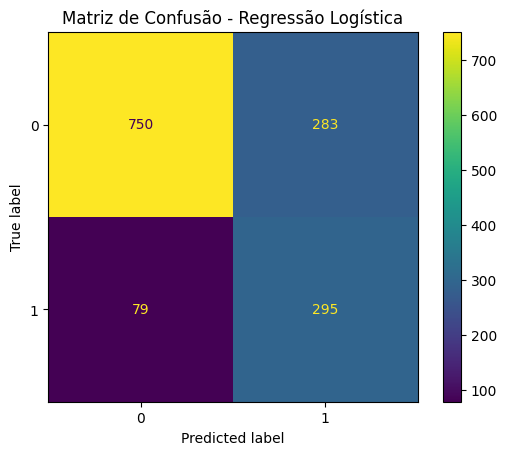

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_log = confusion_matrix(y_test, y_log_reg_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

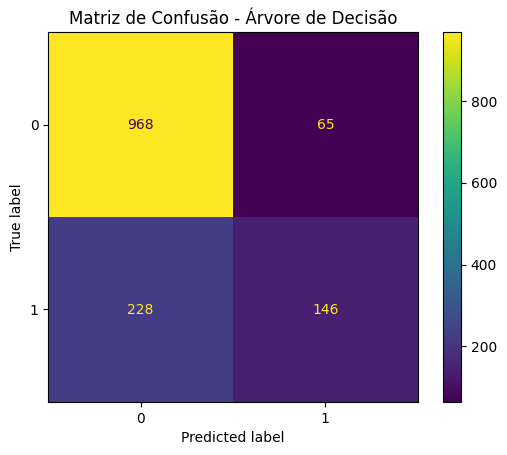

In [86]:
cm_tree = confusion_matrix(y_test, y_tree_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

## Conclusão da Comparação
A comparação dos modelos mostra diferenças importantes entre as métricas de avaliação. O *Dummy Classifier* obteve uma acurácia de 0.73, mas não conseguiu identificar nenhum caso de churn, o que confirma que ele apenas prevê a classe majoritária. A Regressão Logística apresentou uma acurácia ligeiramente superior (0.74), com melhor equilíbrio entre *precision*, *recall* e *F1-score*, destacando-se especialmente no *recall* da classe de churn (0.79), indicando boa capacidade de identificar clientes que realmente cancelam o serviço. A Árvore de Decisão apresentou a maior acurácia geral (0.79) e bons resultados para a classe de não churn, porém teve um *recall* significativamente menor para churn (0.39), refletido também em um *F1-score* mais baixo para essa classe.

 A matriz de confusão reforça essa análise: embora a Árvore de Decisão identifique corretamente mais clientes que permanecem no serviço, ela gera um número elevado de falsos negativos (228), ou seja, clientes que cancelam, mas não são detectados pelo modelo. Já a Regressão Logística apresenta menos falsos negativos (79) e identifica mais casos reais de churn, mostrando-se mais eficaz para o objetivo de detectar clientes com risco de cancelamento, mesmo com uma acurácia geral ligeiramente inferior.

In [87]:
from sklearn.feature_selection import RFECV

model = LogisticRegression(max_iter=1000, class_weight="balanced")

rfecv = RFECV(
    estimator=model,
    step=1,
    cv=5,
    scoring="f1"
)

rfecv.fit(X_train_norm, y_train)

melhores_colunas = X_train_norm.columns[rfecv.support_]
X_train = X_train[melhores_colunas]
X_test = X_test[melhores_colunas]
X_train_norm = X_train_norm[melhores_colunas]
X_test_norm = X_test_norm[melhores_colunas]

In [88]:
log_reg.fit(X_train_norm, y_train)
tree.fit(X_train, y_train)

y_tree_pred = tree.predict(X_test)
y_log_reg_pred = log_reg.predict(X_test_norm)

print(f'Dummy:\n {classification_report(y_test, y_dummy_pred)}')
print(f'Logistic Regression:\n {classification_report(y_test, y_log_reg_pred)}')
print(f'Decision Tree:\n {classification_report(y_test, y_tree_pred)}')

Dummy:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1033
         1.0       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407

Decision Tree:
               precision    recall  f1-score   support

         0.0       0.81      0.94      0.87      1033
         1.0       0.69      0.39      0.50       374

    accuracy                           0.79      1407
   macro avg       0.75      0.66      0.68      1407
weighted avg       0.78     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [91]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = {
    "max_depth": [3,5,7,10],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

grid_tree = GridSearchCV(
    tree,
    param_grid_tree,
    cv=5,
    scoring="f1"
)

grid_tree.fit(X_train, y_train)

print(grid_tree.best_params_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [92]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1"
)

grid_log.fit(X_train_norm, y_train)

print("Best parameters:", grid_log.best_params_)

Best parameters: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}


In [93]:
tree = grid_tree.best_estimator_
tree.fit(X_train, y_train)

log_reg = grid_log.best_estimator_
log_reg.fit(X_train_norm, y_train)

y_tree_pred = tree.predict(X_test)
y_log_reg_pred = log_reg.predict(X_test_norm)

print(f'Dummy:\n {classification_report(y_test, y_dummy_pred)}')
print(f'Logistic Regression:\n {classification_report(y_test, y_log_reg_pred)}')
print(f'Decision Tree:\n {classification_report(y_test, y_tree_pred)}')

Dummy:
               precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1033
         1.0       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407

Decision Tree:
               precision    recall  f1-score   support

         0.0       0.83      0.87      0.85      1033
         1.0       0.60      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


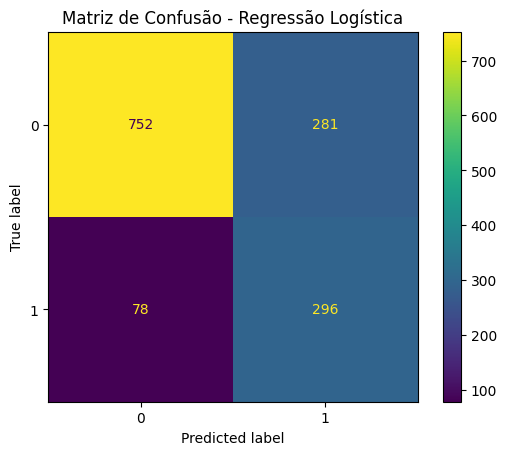

[[Text(0, 0, '752') Text(1, 0, '281')]
 [Text(0, 1, '78') Text(1, 1, '296')]]


In [96]:
cm_log = confusion_matrix(y_test, y_log_reg_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_log)
disp.plot()
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()
print(disp.text_)

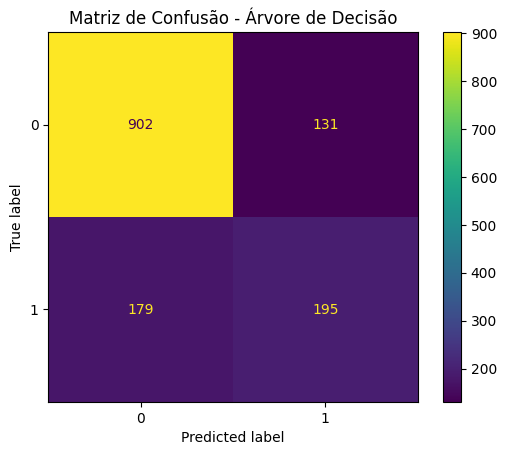

[[Text(0, 0, '902') Text(1, 0, '131')]
 [Text(0, 1, '179') Text(1, 1, '195')]]


In [97]:
cm_tree = confusion_matrix(y_test, y_tree_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot()
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

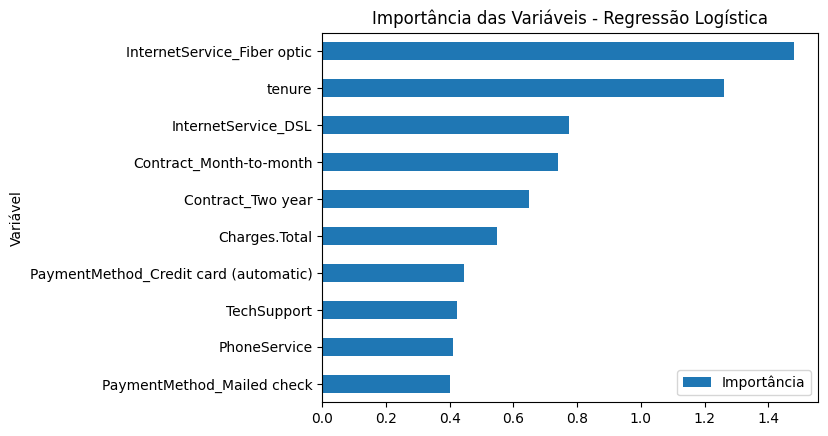

                                 Variável  Coeficiente  Importância
1             InternetService_Fiber optic     1.481401     1.481401
8                                  tenure    -1.260725     1.260725
0                     InternetService_DSL     0.775027     0.775027
2                 Contract_Month-to-month     0.741391     0.741391
3                       Contract_Two year    -0.648569     0.648569
16                          Charges.Total     0.549518     0.549518
5   PaymentMethod_Credit card (automatic)    -0.444772     0.444772
12                            TechSupport    -0.424526     0.424526
9                            PhoneService    -0.409836     0.409836
6              PaymentMethod_Mailed check    -0.402477     0.402477


In [108]:
coef = log_reg.coef_[0]

importance_log = pd.DataFrame({
    "Variável": X_train_norm.columns,
    "Coeficiente": coef
})

importance_log["Importância"] = importance_log["Coeficiente"].abs()
importance_log = importance_log.sort_values(by="Importância", ascending=False)

importance_log.head(10).plot(
    x="Variável",
    y="Importância",
    kind="barh"
)

plt.title("Importância das Variáveis - Regressão Logística")
plt.gca().invert_yaxis()
plt.show()

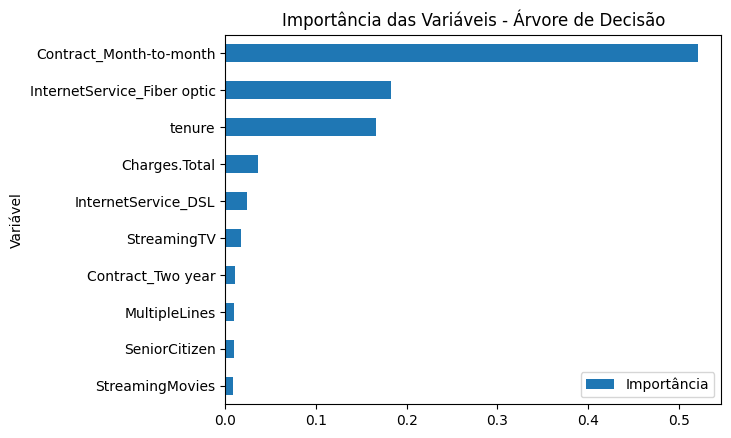

                       Variável  Importância
2       Contract_Month-to-month     0.520735
1   InternetService_Fiber optic     0.183068
8                        tenure     0.166111
16                Charges.Total     0.036472
0           InternetService_DSL     0.023496
13                  StreamingTV     0.016889
3             Contract_Two year     0.010872
10                MultipleLines     0.010048
7                 SeniorCitizen     0.009509
14              StreamingMovies     0.008231


In [107]:
importance_tree = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": tree.feature_importances_
})

importance_tree = importance_tree.sort_values(by="Importância", ascending=False)

importance_tree.head(10).plot(
    x="Variável",
    y="Importância",
    kind="barh"
)

plt.title("Importância das Variáveis - Árvore de Decisão")
plt.gca().invert_yaxis()
plt.show()